
<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Le paramètre d’ordre nématique moyen</strong> <strong>
et les pics de corrélation</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

<span style="font-size: 1.4em; font-weight: 700;"> Fonctionnalités principales</span>
<p style="font-size:1.15em;">

Calcul des intensités moyennes du dossier

Extraction des pics de corrélation

Détermination du paramètre d’ordre sur la valeur de q du premier pic

Importation de l'image de diffusion moyenne,
avec tracé automatique des cercles correspondant aux différents pics

</p>


In [70]:
%matplotlib widget
from utilities_SWING import *
import pandas as pd

**Definition of path, mask file, and output directory (optional)**

In [71]:
instrument='SWING'
#Dossier des H5
h5path='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00161_2026-02-06_09-24-37.nxs'
referencefile='C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/lacroix_00094_2026-02-06_01-27-59.nxs'  # Si reference
mask = 'C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/mask_pyfai.edf'
output_dir='./test_output/'
os.makedirs(output_dir,exist_ok=True)
proc = SAXSProcessor(instrument=instrument ,file=h5path, mask=mask)
#proc = SAXSProcessor(instrument=instrument,reference_file=referencefile ,autosubstract=True,file=h5path, mask=mask)


position moteur :
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
step :
[0.04861111]
[0.04004]
1
Raw data shape: (36, 5, 1083, 1035)
info
1083
1035
No motor positions provided. Update filereaders.py if required
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
(1083, 1035)


**Plot transmission map and grid positions**

position moteur :
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
step :
[0.04861111]
[0.04004]
180
Raw data shape: (36, 5, 1083, 1035)
info
36
5
position moteur :
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
{'X_start': array([36.6002]), 'X_end': array([38.3502]), 'Z_start': array([39.4001]), 'Z_end': array([39.6003])}
step :
[0.04861111]
[0.04004]
180
Raw data shape: (36, 5, 1083, 1035)
info
36
5
matrice de trans
[[0.9679266  0.94129211 0.91000429 0.93426392 0.90742767 0.91749642
  0.96025856 0.98148761 0.9152112  0.9030519  0.95239529 0.90489335
  0.92183397 0.97359155 0.92878473 0.95645738 0.95349483 0.90081538
  0.92122297 0.92759174 0.99613369 0.92964583 0.91601678 0.9082107
  0.93345439 0.89758559 0.93378552 0.94472217 0.94444303 0.92571

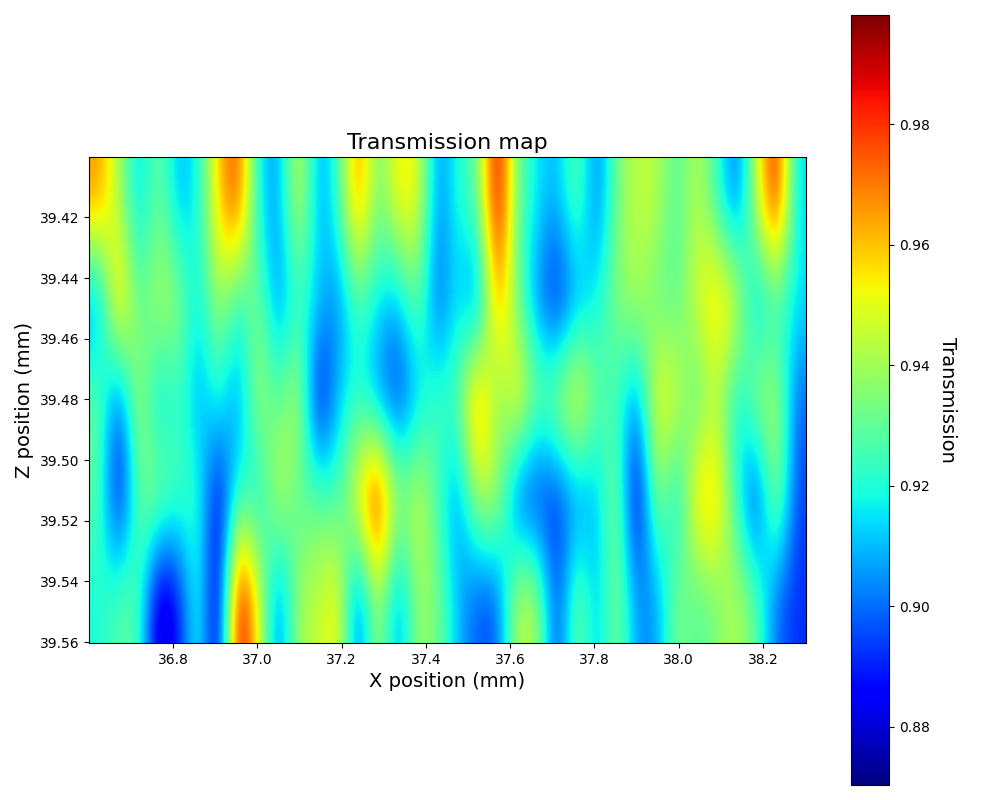

In [72]:
#view_position_grid(h5path, prefix='lacroix')
plot_transmission_map_from_singleh5(h5path, proc)

**Create SAXSProcessor instance with average intensity**

**Plot average SAXS image**

✅ SAXS image saved: C:/Users/lisab/aSAXS/Synchrotron/donnesnxs/saxs_images/S0001_M0099_Img_161.png


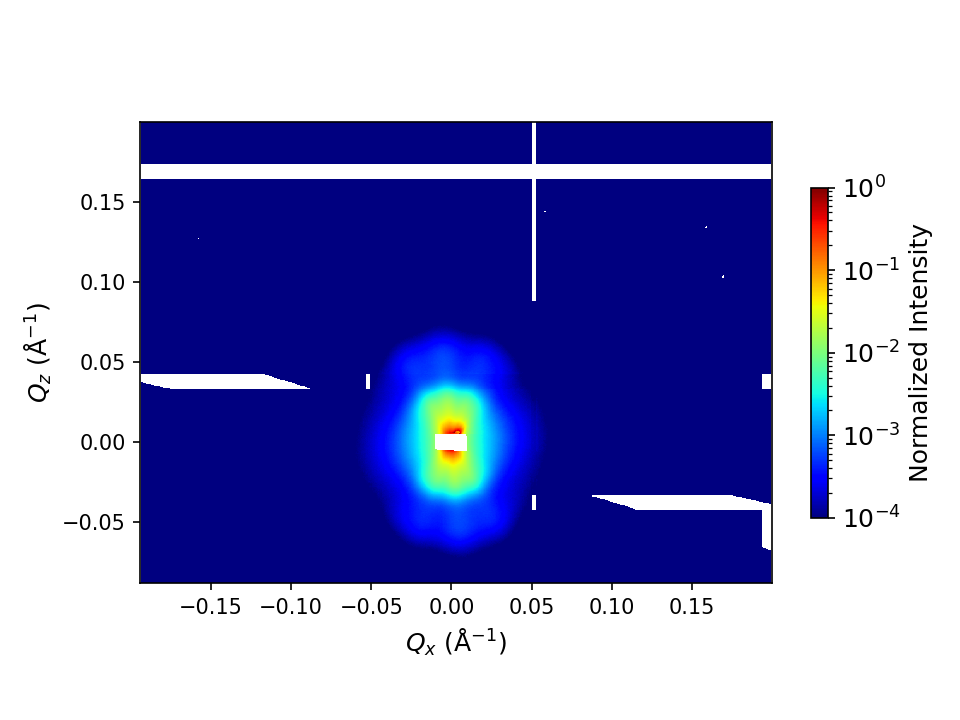

In [73]:
# Use dedicated function to plot average SAXS image
proc.plot2d_vsq()

**Plot and save average radial profile**

From the image above, we can define a q range of interest. This q range can also be determined by plotting the radial profile.
Let's do this first.
Note that the knowledge of this q range is critical for the determination of correlation distances, as it strongly affects results

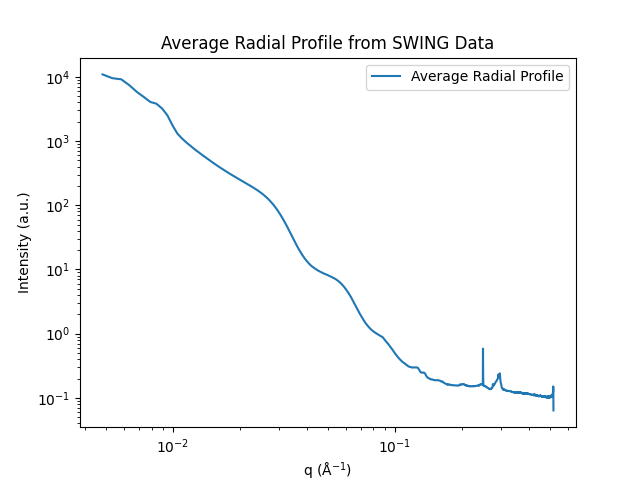

In [74]:
# Plot radial profile for average data
output_dir = os.path.join(proc.path,'average_radial_profile')
q,Ir = proc.extract_radial_profile(azimuth=0, width=360,output_dir=output_dir)

plt.figure()
plt.loglog(q, Ir, label='Average Radial Profile')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Average Radial Profile from SWING Data')
plt.legend()

## Determination of correlation peak

**Knowledge of working q range**

The algorithm for the determination of correlation peak requires the knowledge of workin q range (between qmin and qmax). If qmax is not set,the algorithm may focus on the noisy high q range signal. qmax=0.15 may be a good option. Alos qmin should be considered with care. The user is allowed to play with the algorithm parameters until satisfactory results are obtained.

**Hybrid Method**

Here we use a hybrid method using advantages of 2 methods:
- 2nd derivative method is used to identify peak positions (fast and efficient)
- each peak is refined using Split Pseudo Voigt functions to ensure accurate determination of correlation distance (peak identification with this method is not optimum)

There is a large number of arguments in the function. The most relevants are the followings:
- qmin and qmax defining the q window
- nb_peaks defining the number of peaks to search in the specified q window
- method = 'hybrid', 'spv', or 'derivative' depending on the method selected for the computation
- substract_power_law (bool)
- fit_window_width


Playing with these parameters should be enough to obtain satisafctory results. In cas of issues, read dedicated documentation (file parameter_guide.py).


In [75]:
get_results = detect_peaks_hybrid_interactive(
    proc,
    nb_peaks_init=2,
    qmin_init=0.03,
    qmax_init=0.15,
    fit_window_width_init=1,
    prominence=0.8,
    distance_pts=20)




Output()

In [76]:
# Après avoir ajusté les sliders, récupérer les résultats
results_dict = get_results()
distances = results_dict['distances']
distances_std = results_dict['distances_std']
hybrid_results = results_dict['hybrid_results']
peaklist = results_dict['peaklist']

print(peaklist)

[0.02690462 0.05670672]


## Nematic order parameter

**Selection of working qvalue**

We select the first pealk returned by the calculation of correlation distances

In [77]:
qvalues = peaklist

**Form factor parameters**

Used for nematic order calculation

In [78]:
# To be completed with actual values (data usually extracted from TEM images)
AS = 8.38
diametre = 183
diametre_pd = 0.1421
L_pd=0.1569  

**Nematic Order Calculation**

It is computed for the first peak


c:\Users\lisab\anaconda3\envs\saxs\Lib\site-packages\pyFAI\integrator\azimuthal.py:615: RuntimeWarning: invalid value encountered in divide
  intensity = sum_signal / sum_normalization



Azimuthal profile completeness check:
  Status: INCOMPLETE
  Too many invalid points (29.8% are NaN/0, threshold=10.0%)
  → Mirror symmetry: ENABLED
Main nanorod orientation is -22.971294410250295

Computing cylinder form factor...


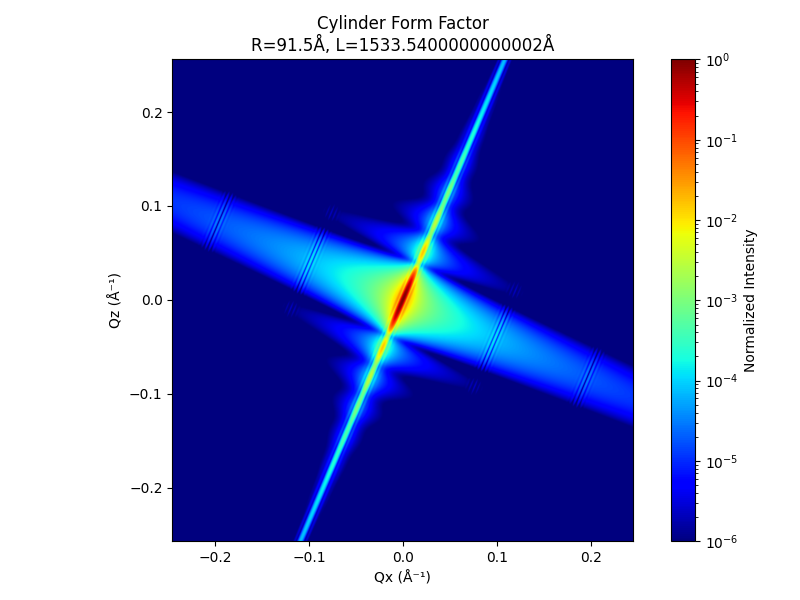


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in C:/Users/lisab/aSAXS/Synchrotron/donnesnxs\azimuthal_profiles\S0001_M0099_B=0_Img161_nematic_determination.png

Fitting results:
x0: -94.12054056855689
S: 0.708710572243026
R2: 0.947454258266675


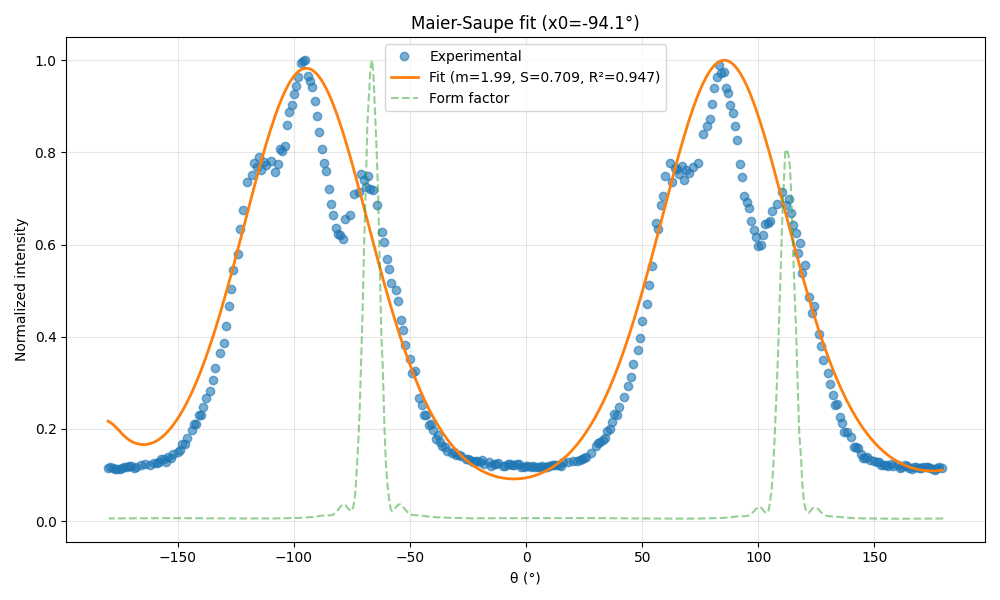

In [79]:
threshold = 0.01
plot = True
apply_mirror = False 
verbose = False

#calcul de S pour tous les pics
'''
S_array = np.zeros(len(qvalues))
for i, qvalue in enumerate(qvalues):
    S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = qvalue, 
        threshold = threshold,
        radius = radius,
        L = L,
        radius_pd = radius_pd,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )
    S_array[i] = S'''

#calcul de S le premier pic

S, mean_angle, dict = compute_nematic_parameter(
        processor = proc,
        qvalue = peaklist[0], 
        threshold = threshold,
        radius = diametre/2,
        L = AS*diametre,
        radius_pd = diametre_pd/2,
        L_pd= L_pd,
        plot = plot,
        verbose = True
        )



## Store results in a dict or csv???

**Metadata**

Dans les exemple de data SWING à notre disposition, on ne fait pas varier le champ magnétique.

J'ai ajouté à la classe h5File_Swing une méthode pour extraire la valeur de B de l'attribut samplename.

Lors de l'acquisition des data, au moment de remplir le champ de référence échantillon, il vous faudra ajouter le champ B à la réf échantillon sous un format de style **'*_xxxmT*'**. 
 
 A la lecture du fichier h5, on aura alors accès à la valeur de B via l'attribut B de SAXSProcessor.

**Stockage csv**

J'ai ici indiqué un chemin vers un fichier csv fictif. A modifier


In [81]:
# save data in dictionary

results={
    'samplename': proc.samplename,
    'B (mT)': proc.B,
    'distance (A)': distances, # array of distances
    'distance_error (A)': distances_std, # array of errors
    'nematic_parameter': S, # array of nematic order parameters
    'mean orientation' : mean_angle 
}

# add dictionary to existing csv or create new one
csv_file = os.path.join(proc.path,'analysis_results.csv')  # A MODIFIER, je ne sais poas où vous allez stocker ce fichier.
if os.path.exists(csv_file):
    df_existing = pd.read_csv(csv_file)
    df_new = pd.DataFrame([results])
    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined.to_csv(csv_file, index=False)
    # visualize added line
    print(df_new)
else:
    df = pd.DataFrame([results])
    df.to_csv(csv_file, index=False)


    samplename  B (mT)                             distance (A)  \
0  S0001_M0099       0  [233.5355641456491, 110.80143332397499]   

                       distance_error (A)  nematic_parameter  mean orientation  
0  [11.676778207282455, 5.54007166619875]           0.708711        -22.971294  


## Batch function

All these steps have been wrapped up in a single function "global_analyis", that could be further used for batch analysis. 
This function takes a total of 31 arguments, decomposed as follows:
- 1 arg for csv_file path where results are stored (csv_file)
- 2 args to define the list of files to be analyzed (h5path, prefix='lacroix')
- 4 args to initialize SAXSProcessor instance (mask, referencefile=None, k=1, autosubstract=True)
- 17 args(!) to initialize the hybrid method for correlation distance calculation. (mandatory ones: nb_peaks, qmin, qmax -- other parameters can keep their default value as a start)
- 5 args for nematic order calculation (radius, L, radius_pd, L_pd, threshold) - mostly used for form factor calculation
- 2 args for output (plot, verbose)

SUMMARY: There are 10 mandatory arguments:
- csv_file: path to file where results are appended
- h5path: path to data directory
- mask: path to mask file (pyfai edf format)
- nb_peaks: number of peaks for correlation distance determination
- qmin (=0.01) - qmax (=0.15): fitting window for correlation distance determination
- Form factor parameters (radius, L, radius_pd, L_pd)

In [ ]:
'''# Alternatively, use global_analysis function to perform all steps at once
results = global_analysis(
    csv_file=csv_file,
    h5path=h5path,
    mask=mask,
    nb_peaks=2,
    qmin=0.02,
    qmax=0.09,
    azimuth=90,
    width=30,
    method='hybrid',
    radius=radius,
    L=L,
    radius_pd=radius_pd,
    L_pd=L_pd,
    plot=False,
    verbose=False)'''